In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, BayesianRidge
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error

# 1. Load and Prepare Data
df = pd.read_csv("data.csv")
df['Date'] = pd.to_datetime(df['Date'])
df['Price_Movement'] = df['Close'].shift(-1) - df['Close']
df.dropna(inplace=True)

features = [
    'News - Positive Sentiment', 'News - Negative Sentiment', 
    'News - New Products', 'News - Layoffs', 'News - Analyst Comments',
    'News - Stocks', 'News - Dividends', 'News - Corporate Earnings',
    'News - Mergers & Acquisitions', 'News - Store Openings', 
    'News - Product Recalls', 'News - Adverse Events', 
    'News - Personnel Changes', 'News - Stock Rumors'
]
X = df[features]
y = df['Price_Movement']

# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Plot subset
subset = min(200, len(y_test))  # first 200 points only

Linear Regression MSE: 663.3067


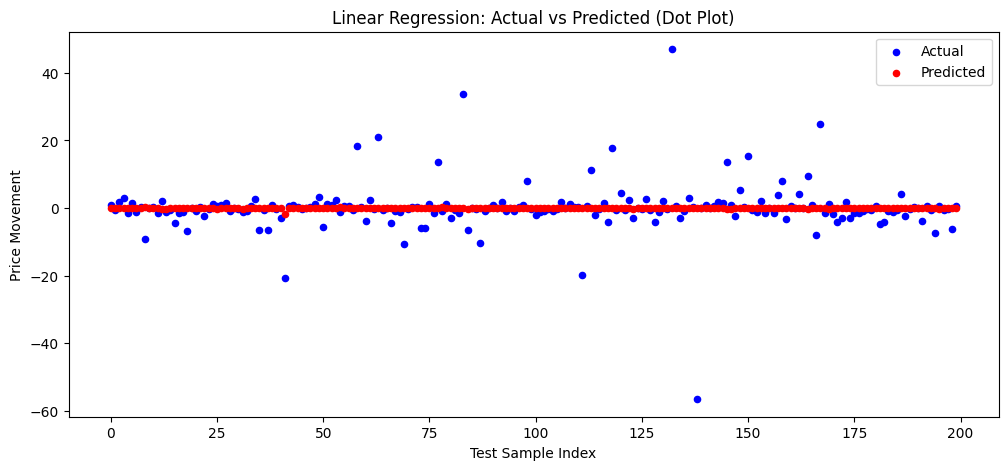

In [2]:
# 3. Linear Regression
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
y_pred_lin = lin_model.predict(X_test)
print(f"Linear Regression MSE: {mean_squared_error(y_test, y_pred_lin):.4f}")

plt.figure(figsize=(12,5))
plt.scatter(range(subset), y_test.values[:subset], label="Actual", color='blue', s=20)
plt.scatter(range(subset), y_pred_lin[:subset], label="Predicted", color='red', s=20)
plt.title("Linear Regression: Actual vs Predicted (Dot Plot)")
plt.xlabel("Test Sample Index")
plt.ylabel("Price Movement")
plt.legend()
plt.show()

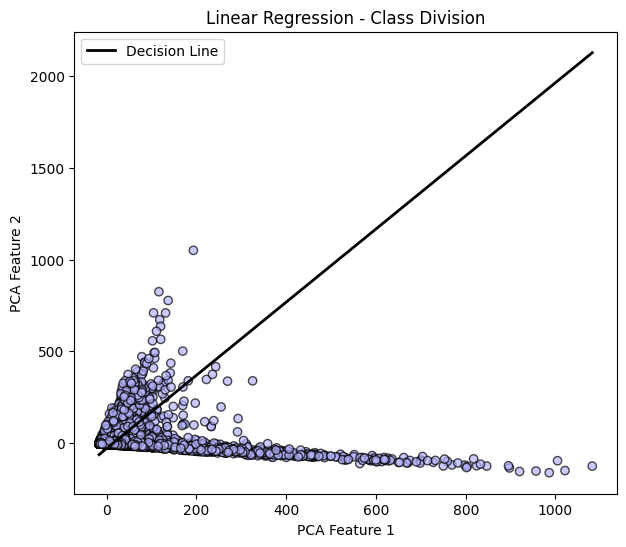

In [7]:
# Reduce dimensions for visualization
from sklearn.decomposition import PCA
import numpy as np
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train)
X_test_2d = pca.transform(X_test)

# Train Linear Regression
lin_model = LinearRegression()
lin_model.fit(X_train_2d, y_train)

# Plot decision boundary
plt.figure(figsize=(7,6))
plt.scatter(X_test_2d[:,0], X_test_2d[:,1], c=y_test, cmap="bwr", alpha=0.7, edgecolor="k")

# Create line
x_line = np.linspace(X_test_2d[:,0].min(), X_test_2d[:,0].max(), 100)
y_line = -(lin_model.coef_[0]/lin_model.coef_[1])*x_line - (lin_model.intercept_/lin_model.coef_[1])
plt.plot(x_line, y_line, color="black", linewidth=2, label="Decision Line")

plt.title("Linear Regression - Class Division")
plt.xlabel("PCA Feature 1")
plt.ylabel("PCA Feature 2")
plt.legend()
plt.show()

Bayesian Regression MSE: 663.3570


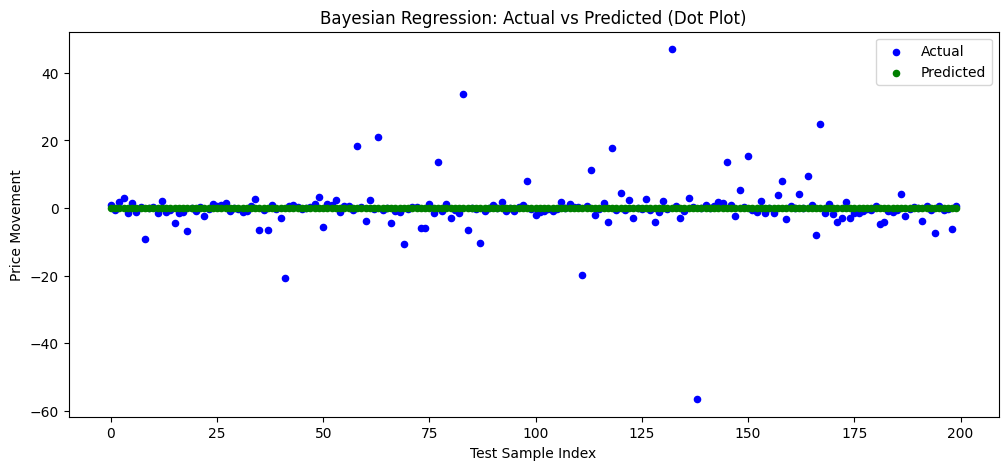

In [3]:
# 4. Bayesian Regression
bayes_model = BayesianRidge()
bayes_model.fit(X_train, y_train)
y_pred_bayes = bayes_model.predict(X_test)
print(f"Bayesian Regression MSE: {mean_squared_error(y_test, y_pred_bayes):.4f}")

plt.figure(figsize=(12,5))
plt.scatter(range(subset), y_test.values[:subset], label="Actual", color='blue', s=20)
plt.scatter(range(subset), y_pred_bayes[:subset], label="Predicted", color='green', s=20)
plt.title("Bayesian Regression: Actual vs Predicted (Dot Plot)")
plt.xlabel("Test Sample Index")
plt.ylabel("Price Movement")
plt.legend()
plt.show()

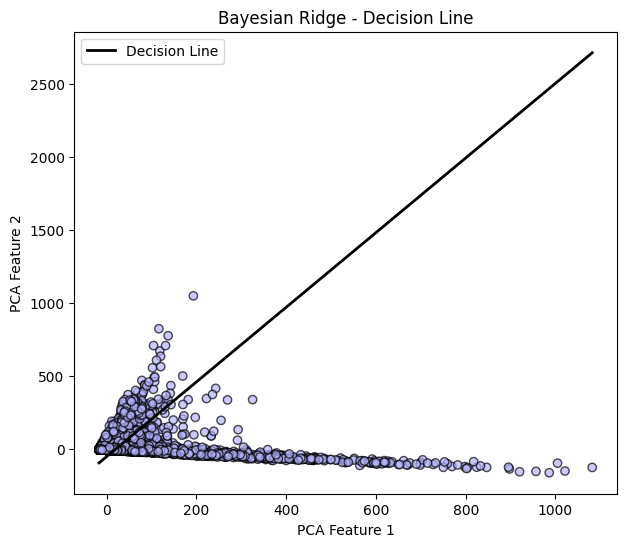

In [8]:
# 1. Bayesian Ridge with Decision Line

from sklearn.decomposition import PCA
from sklearn.linear_model import BayesianRidge
import numpy as np
import matplotlib.pyplot as plt

# Reduce dimensions using PCA
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train)
X_test_2d = pca.transform(X_test)

# Train Bayesian Ridge
bayes_model = BayesianRidge()
bayes_model.fit(X_train_2d, y_train)

# Plot Decision Line
plt.figure(figsize=(7,6))
plt.scatter(X_test_2d[:,0], X_test_2d[:,1], c=y_test, cmap="bwr", alpha=0.7, edgecolor="k")

x_line = np.linspace(X_test_2d[:,0].min(), X_test_2d[:,0].max(), 100)
y_line = -(bayes_model.coef_[0]/bayes_model.coef_[1])*x_line - (bayes_model.intercept_/bayes_model.coef_[1])

plt.plot(x_line, y_line, color="black", linewidth=2, label="Decision Line")
plt.title("Bayesian Ridge - Decision Line")
plt.xlabel("PCA Feature 1")
plt.ylabel("PCA Feature 2")
plt.legend()
plt.show()

SVM Regression MSE: 663.6565


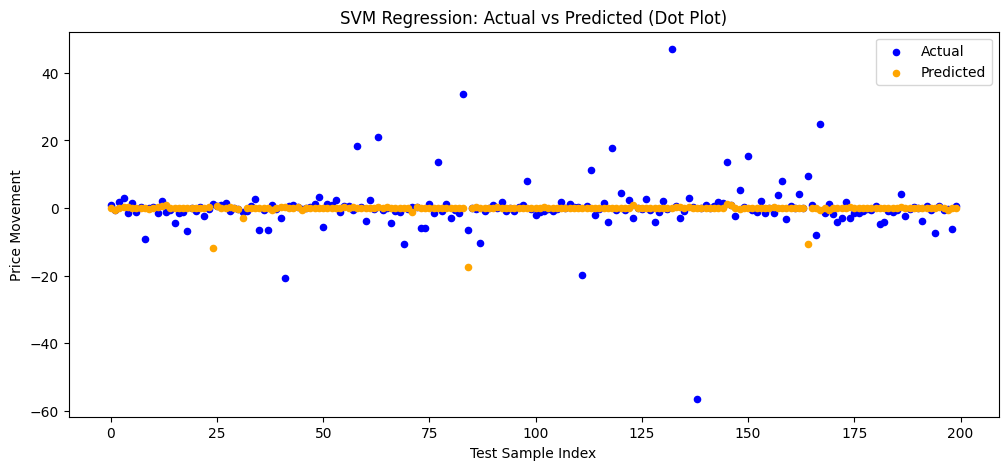

In [4]:
# 5. SVM Regression
svr_subset = min(500, len(X_train))  # train SVR on subset
svm_model = SVR(kernel='linear')
svm_model.fit(X_train[:svr_subset], y_train[:svr_subset])
y_pred_svm = svm_model.predict(X_test)
print(f"SVM Regression MSE: {mean_squared_error(y_test, y_pred_svm):.4f}")

plt.figure(figsize=(12,5))
plt.scatter(range(subset), y_test.values[:subset], label="Actual", color='blue', s=20)
plt.scatter(range(subset), y_pred_svm[:subset], label="Predicted", color='orange', s=20)
plt.title("SVM Regression: Actual vs Predicted (Dot Plot)")
plt.xlabel("Test Sample Index")
plt.ylabel("Price Movement")
plt.legend()
plt.show()

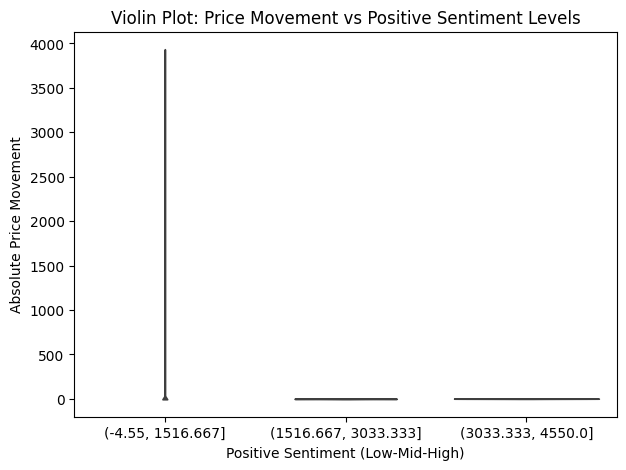

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Add a new feature: absolute price movement (magnitude of change)
df['abs_price_movement'] = df['Price_Movement'].abs()

# 2. Violin plot: Price movement by positive sentiment
plt.figure(figsize=(7,5))
sns.violinplot(x=pd.cut(df['News - Positive Sentiment'], bins=3), y='abs_price_movement', data=df, inner='quartile')
plt.title('Violin Plot: Price Movement vs Positive Sentiment Levels')
plt.xlabel('Positive Sentiment (Low-Mid-High)')
plt.ylabel('Absolute Price Movement')
plt.show()

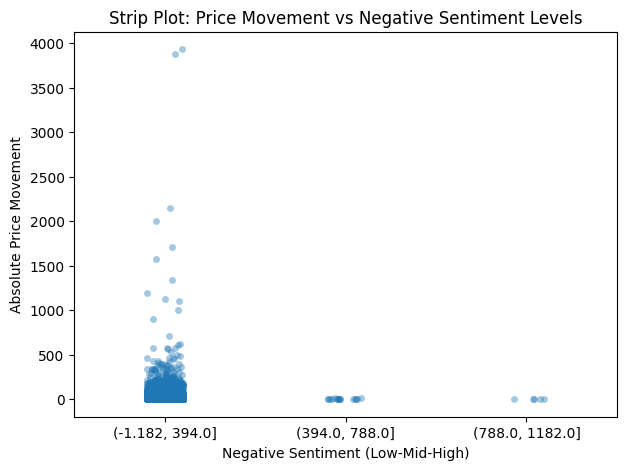

In [10]:
# 3. Strip plot: Price movement vs negative sentiment
plt.figure(figsize=(7,5))
sns.stripplot(x=pd.cut(df['News - Negative Sentiment'], bins=3), y='abs_price_movement', data=df, jitter=True, alpha=0.4)
plt.title('Strip Plot: Price Movement vs Negative Sentiment Levels')
plt.xlabel('Negative Sentiment (Low-Mid-High)')
plt.ylabel('Absolute Price Movement')
plt.show()

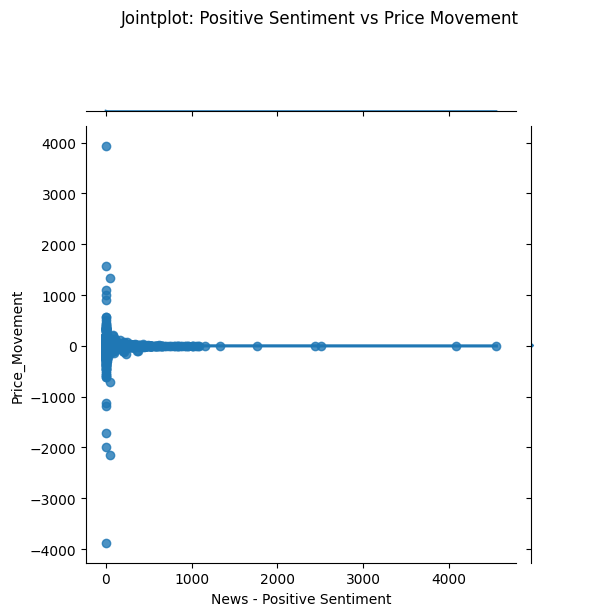

In [11]:
# 4. Jointplot: Regression between Positive Sentiment and Price Movement
sns.jointplot(x='News - Positive Sentiment', y='Price_Movement', data=df, kind='reg', height=6)
plt.suptitle('Jointplot: Positive Sentiment vs Price Movement', y=1.02)
plt.show()

In [ ]:
# 5. Pairplot: Multiple news sentiment features vs price movement
sns.pairplot(df[['News - Positive Sentiment','News - Negative Sentiment','Price_Movement']])
plt.suptitle('Pairplot: Sentiment vs Price Movement', y=1.02)
plt.show()
